# Air density from 0 to 80 km: why one exponential is not enough

A single exponential assumes that the atmosphere has one constant scale height. That is a useful approximation near the ground, but it cannot describe the whole atmosphere because the temperature—and therefore the scale height—changes with altitude.

This notebook first repeats two empirical fits, then calculates density using the piecewise temperature structure of the **U.S. Standard Atmosphere 1976**. The last calculation is included as a demonstration; it is well beyond what students are expected to construct themselves.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

plt.style.use("seaborn-v0_8-whitegrid")

## Load the tabulated data

The columns in `density.txt` are altitude, temperature, gravitational acceleration, pressure, density, and dynamic viscosity. In this table, the density column is expressed in units of $0.1\,\mathrm{kg/m^3}$: the sea-level value 12.25 therefore means $1.225\,\mathrm{kg/m^3}$.

In [2]:
data_path = Path("density.txt")
if not data_path.exists():
    data_path = Path("JupyterNotebooks/Week1/density.txt")

altitude, temperature_C, gravity, pressure_table, density_table, viscosity = np.loadtxt(data_path).T
density = 0.1 * density_table  # convert to kg/m^3

print(f"Loaded {len(altitude)} points from {altitude.min()/1000:.0f} to {altitude.max()/1000:.0f} km.")
print(f"Sea-level density: {density[0]:.4f} kg/m^3")

Loaded 20 points from 0 to 80 km.
Sea-level density: 1.2250 kg/m^3


## 1. Two empirical approximations

We fit in log-density so that the small high-altitude values matter instead of letting the dense, low-altitude points dominate the optimization. The models are

$$\rho=\rho_0 e^{-ah}$$

and

$$\rho=\rho_0 e^{-ah+b h^{3/2}}.$$

The second expression is more flexible, but neither model contains the changing temperature structure of the real atmosphere.

In [3]:
def log_exponential(h, log_rho0, a):
    return log_rho0 - a * np.asarray(h)

def log_curved_exponential(h, log_rho0, a, b):
    h = np.asarray(h)
    return log_rho0 - a * h + b * h**1.5

p_exp, _ = curve_fit(log_exponential, altitude, np.log(density), p0=[np.log(1.225), 1.2e-4])
p_curve, _ = curve_fit(log_curved_exponential, altitude, np.log(density),
                       p0=[np.log(1.225), 1.2e-4, 0.0])

def rho_exponential(h):
    return np.exp(log_exponential(h, *p_exp))

def rho_curved_exponential(h):
    return np.exp(log_curved_exponential(h, *p_curve))

print("Simple exponential parameters [log(rho_0), a]:", p_exp)
print("Curved exponential parameters [log(rho_0), a, b]:", p_curve)

Simple exponential parameters [log(rho_0), a]: [3.69950272e-01 1.41490049e-04]
Curved exponential parameters [log(rho_0), a, b]: [3.90987033e-01 1.45629252e-04 1.52243348e-08]


## 2. A piecewise physical model

Hydrostatic equilibrium and the ideal-gas law give

$$\frac{dp}{dH}=-\rho g_0, \qquad p=\rho R T.$$

The Standard Atmosphere specifies a linear temperature law within each layer, $T(H)=T_b+L_b(H-H_b)$. Integrating the equations gives

$$p=p_b\left(\frac{T_b}{T}\right)^{g_0/(R L_b)} \quad (L_b\ne0),$$

or, for an isothermal layer,

$$p=p_b\exp\left[-\frac{g_0(H-H_b)}{RT_b}\right].$$

Finally, $\rho=p/(RT)$. Here $H$ is **geopotential altitude**, related to geometric altitude $z$ by $H=r_0z/(r_0+z)$. This change of coordinate absorbs the decrease of gravity with height into a constant standard gravity $g_0$.

In [4]:
# U.S. Standard Atmosphere 1976 constants and layer definitions
G0 = 9.80665          # standard gravity, m/s^2
R_AIR = 287.05287     # specific gas constant for dry air, J/(kg K)
EARTH_RADIUS = 6_356_766.0  # effective Earth radius, m

# Base geopotential altitudes (m) and lapse rates (K/m)
H_BASE = np.array([0, 11_000, 20_000, 32_000, 47_000, 51_000, 71_000, 84_852.0])
LAPSE = np.array([-0.0065, 0.0, 0.0010, 0.0028, 0.0, -0.0028, -0.0020])

T_BASE = np.empty_like(H_BASE)
P_BASE = np.empty_like(H_BASE)
T_BASE[0], P_BASE[0] = 288.15, 101_325.0

# Propagate temperature and pressure continuously from one layer base to the next.
for i, lapse in enumerate(LAPSE):
    dH = H_BASE[i + 1] - H_BASE[i]
    T_BASE[i + 1] = T_BASE[i] + lapse * dH
    if lapse == 0.0:
        P_BASE[i + 1] = P_BASE[i] * np.exp(-G0 * dH / (R_AIR * T_BASE[i]))
    else:
        P_BASE[i + 1] = P_BASE[i] * (T_BASE[i] / T_BASE[i + 1])**(G0 / (R_AIR * lapse))

for h, T, p in zip(H_BASE, T_BASE, P_BASE):
    print(f"H_b = {h/1000:6.3f} km, T_b = {T:7.2f} K, p_b = {p:11.5g} Pa")

H_b =  0.000 km, T_b =  288.15 K, p_b =  1.0132e+05 Pa
H_b = 11.000 km, T_b =  216.65 K, p_b =       22632 Pa
H_b = 20.000 km, T_b =  216.65 K, p_b =      5474.9 Pa
H_b = 32.000 km, T_b =  228.65 K, p_b =      868.02 Pa
H_b = 47.000 km, T_b =  270.65 K, p_b =      110.91 Pa
H_b = 51.000 km, T_b =  270.65 K, p_b =      66.939 Pa
H_b = 71.000 km, T_b =  214.65 K, p_b =      3.9564 Pa
H_b = 84.852 km, T_b =  186.95 K, p_b =     0.37338 Pa


In [5]:
def geometric_to_geopotential(z):
    """Convert geometric altitude z (m) to geopotential altitude H (m)."""
    z = np.asarray(z, dtype=float)
    return EARTH_RADIUS * z / (EARTH_RADIUS + z)

def standard_atmosphere(z):
    """Return temperature (K), pressure (Pa), and density (kg/m^3)."""
    z = np.asarray(z, dtype=float)
    H = geometric_to_geopotential(z)
    if np.any((H < H_BASE[0]) | (H > H_BASE[-1])):
        raise ValueError("This implementation is valid from sea level to 84.852 km geopotential altitude.")

    layer = np.searchsorted(H_BASE[1:], H, side="right")
    layer = np.minimum(layer, len(LAPSE) - 1)
    dH = H - H_BASE[layer]
    lapse = LAPSE[layer]
    T = T_BASE[layer] + lapse * dH

    isothermal = lapse == 0.0
    p = np.empty_like(H)
    p[isothermal] = P_BASE[layer[isothermal]] * np.exp(
        -G0 * dH[isothermal] / (R_AIR * T_BASE[layer[isothermal]])
    )
    p[~isothermal] = P_BASE[layer[~isothermal]] * (
        T_BASE[layer[~isothermal]] / T[~isothermal]
    )**(G0 / (R_AIR * lapse[~isothermal]))
    rho = p / (R_AIR * T)
    return T, p, rho

temperature_model, pressure_model, density_model = standard_atmosphere(altitude)

Notice that this is not a many-parameter curve fit. Once the layer boundaries, lapse rates, and sea-level conditions are specified, the density follows from the physics. The complication is in the piecewise temperature model.

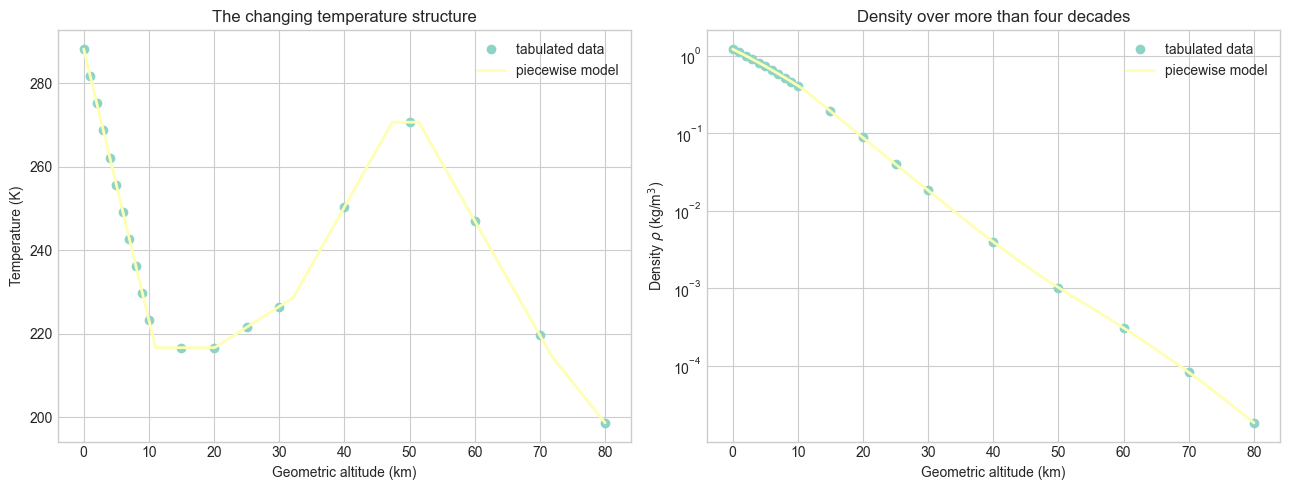

In [6]:
z_plot = np.linspace(0, 80_000, 1601)
T_plot, p_plot, rho_plot = standard_atmosphere(z_plot)

fig, (ax_T, ax_rho) = plt.subplots(1, 2, figsize=(13, 5))

ax_T.plot(altitude / 1000, temperature_C + 273.15, "o", label="tabulated data")
ax_T.plot(z_plot / 1000, T_plot, lw=2, label="piecewise model")
ax_T.set(xlabel="Geometric altitude (km)", ylabel="Temperature (K)",
         title="The changing temperature structure")
ax_T.legend()

ax_rho.semilogy(altitude / 1000, density, "o", label="tabulated data")
ax_rho.semilogy(z_plot / 1000, rho_plot, lw=2, label="piecewise model")
ax_rho.set(xlabel="Geometric altitude (km)", ylabel=r"Density $\rho$ (kg/m$^3$)",
           title="Density over more than four decades")
ax_rho.legend()

fig.tight_layout()

## 3. Compare all three models

A logarithmic density axis shows the full altitude range. The fractional residual is more revealing: a small vertical separation on the logarithmic plot can still be a large relative error.

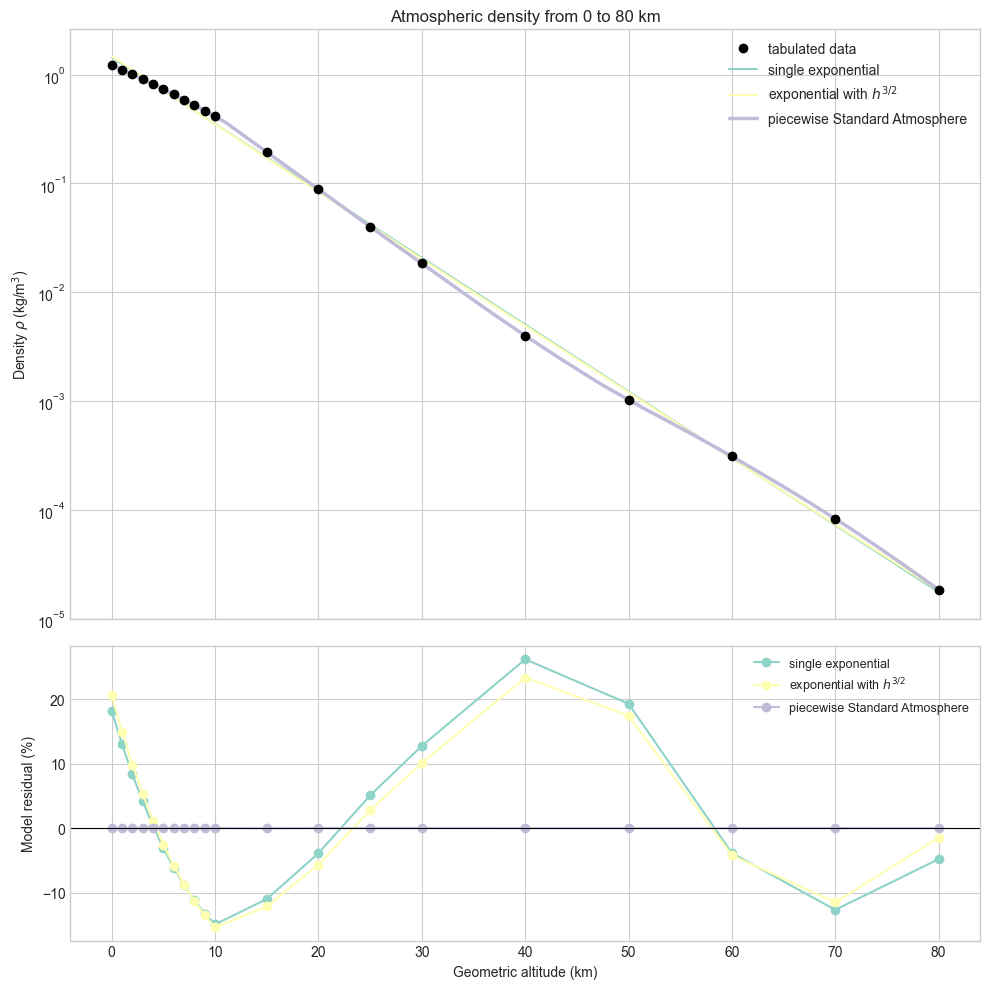

In [7]:
fig, (ax, ax_res) = plt.subplots(2, 1, figsize=(10, 10), sharex=True,
                                    gridspec_kw={"height_ratios": [2, 1]})

ax.semilogy(altitude / 1000, density, "ko", label="tabulated data", zorder=5)
ax.semilogy(z_plot / 1000, rho_exponential(z_plot), label="single exponential")
ax.semilogy(z_plot / 1000, rho_curved_exponential(z_plot), label=r"exponential with $h^{3/2}$")
ax.semilogy(z_plot / 1000, rho_plot, lw=2.5, label="piecewise Standard Atmosphere")
ax.set(ylabel=r"Density $\rho$ (kg/m$^3$)", title="Atmospheric density from 0 to 80 km")
ax.legend()

models = {
    "single exponential": rho_exponential(altitude),
    r"exponential with $h^{3/2}$": rho_curved_exponential(altitude),
    "piecewise Standard Atmosphere": density_model,
}
for label, prediction in models.items():
    ax_res.plot(altitude / 1000, 100 * (prediction - density) / density, "o-", label=label)
ax_res.axhline(0, color="black", lw=0.8)
ax_res.set(xlabel="Geometric altitude (km)", ylabel="Model residual (%)")
ax_res.legend(fontsize=9)

fig.tight_layout()

In [8]:
print("Residual summary at the tabulated altitudes")
print("-" * 62)
for label, prediction in models.items():
    percent_error = 100 * (prediction - density) / density
    print(f"{label:34s}  RMS = {np.sqrt(np.mean(percent_error**2)):8.3f}%"
          f"   max |error| = {np.max(np.abs(percent_error)):8.3f}%")

Residual summary at the tabulated altitudes
--------------------------------------------------------------
single exponential                  RMS =   11.878%   max |error| =   26.214%
exponential with $h^{3/2}$          RMS =   11.702%   max |error| =   23.377%
piecewise Standard Atmosphere       RMS =    0.014%   max |error| =    0.044%


## Conclusion

The simple exponential is valuable because it introduces the idea of an atmospheric scale height. Adding an $h^{3/2}$ term makes the curve more flexible, but it still asks one smooth formula to imitate several physically different layers.

The piecewise calculation works across 0–80 km because it includes the atmospheric temperature structure, enforces continuity of pressure at every boundary, and distinguishes geometric from geopotential altitude. Its tiny remaining differences from `density.txt` are due to rounding in the table.

So the nicer version of **“it’s complicated”** is: atmospheric density is governed by simple physics locally, but the temperature profile that feeds that physics is genuinely layered.